In [ ]:
import kagglehub
import pandas as pd
import os

# 1. Veri setini indir (Kaggle klasörüne iner)
path = kagglehub.dataset_download("nicapotato/womens-ecommerce-clothing-reviews")

# 2. İndirilen yerdeki CSV dosyasının adını bul
# Genellikle 'Womens Clothing E-Commerce Reviews.csv' olur
files = [f for f in os.listdir(path) if f.endswith('.csv')]
file_path = os.path.join(path, files[0])

# 3. Veriyi Pandas ile oku
# 'index_col=0' diyoruz çünkü bu veri setinde ilk sütun gereksiz bir ID sütunudur.
df = pd.read_csv(file_path, index_col=0)

# 4. Sadece ihtiyacımız olan sütunları seçelim (RAM tasarrufu)
# 'Review Text' (Yorum) ve 'Rating' (Yıldız) bizim için yeterli.
df = df[['Review Text', 'Rating']].dropna()

print("Veri Seti Başarıyla Yüklendi!")
print(f"Toplam Satır Sayısı: {len(df)}")
print(df.head())

Using Colab cache for faster access to the 'womens-ecommerce-clothing-reviews' dataset.
Veri Seti Başarıyla Yüklendi!
Toplam Satır Sayısı: 22641
                                         Review Text  Rating
0  Absolutely wonderful - silky and sexy and comf...       4
1  Love this dress!  it's sooo pretty.  i happene...       5
2  I had such high hopes for this dress and reall...       3
3  I love, love, love this jumpsuit. it's fun, fl...       5
4  This shirt is very flattering to all due to th...       5


In [ ]:
# İlk 10 satırı tüm sütunlarıyla birlikte göster
df_head = df.head(10)

# Daha temiz bir çıktı için formatlayalım
for i, row in df_head.iterrows():
    print(f"[{i}] Rating: {row['Rating']}")
    print(f"Review: {row['Review Text'][:150]}...") # Metnin sadece ilk 150 karakterini görelim
    print("-" * 50)

[0] Rating: 4
Review: Absolutely wonderful - silky and sexy and comfortable...
--------------------------------------------------
[1] Rating: 5
Review: Love this dress!  it's sooo pretty.  i happened to find it in a store, and i'm glad i did bc i never would have ordered it online bc it's petite.  i b...
--------------------------------------------------
[2] Rating: 3
Review: I had such high hopes for this dress and really wanted it to work for me. i initially ordered the petite small (my usual size) but i found this to be ...
--------------------------------------------------
[3] Rating: 5
Review: I love, love, love this jumpsuit. it's fun, flirty, and fabulous! every time i wear it, i get nothing but great compliments!...
--------------------------------------------------
[4] Rating: 5
Review: This shirt is very flattering to all due to the adjustable front tie. it is the perfect length to wear with leggings and it is sleeveless so it pairs ...
---------------------------------------

In [ ]:
!pip install transformers datasets torch scikit-learn

In [ ]:
import nltk
import re
from nltk.corpus import stopwords

# Gerekli dil paketini indirelim
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def temizle(text):
    # 1. Küçük harfe çevir
    text = text.lower()
    # 2. Gereksiz karakterleri ve sayıları temizle (Sadece harfler kalsın)
    text = re.sub(r'[^a-z\s]', '', text)
    # 3. Kelimelere ayır ve stopwords'leri filtrele
    words = text.split()
    cleaned_words = [w for w in words if w not in stop_words]
    # 4. Tekrar birleştir
    return " ".join(cleaned_words)

# Uygulayalım
print("Veriler temizleniyor...")
df['Clean_Review'] = df['Review Text'].apply(temizle)

# Duygu analizi için hedef sütunu oluşturalım:
# 4 ve 5 yıldız -> 1 (Olumlu)
# 1, 2 ve 3 yıldız -> 0 (Olumsuz)
df['Sentiment'] = df['Rating'].apply(lambda x: 1 if x > 3 else 0)

print("İşlem tamam! Temizlenmiş veriden bir örnek:")
print("-" * 30)
print(f"Orijinal: {df['Review Text'].iloc[1][:100]}...")
print(f"Temizlenmiş: {df['Clean_Review'].iloc[1][:100]}...")
print(f"Duygu Etiketi: {df['Sentiment'].iloc[1]}")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Veriler temizleniyor...
İşlem tamam! Temizlenmiş veriden bir örnek:
------------------------------
Orijinal: Love this dress!  it's sooo pretty.  i happened to find it in a store, and i'm glad i did bc i never...
Temizlenmiş: love dress sooo pretty happened find store im glad bc never would ordered online bc petite bought pe...
Duygu Etiketi: 1


Sentiment
1    17448
0     5193
Name: count, dtype: int64


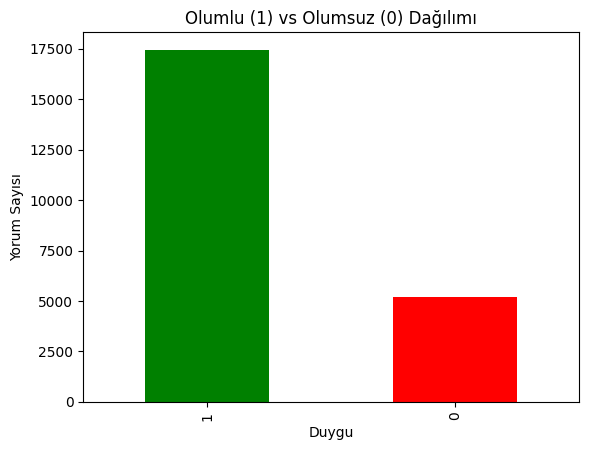

In [ ]:
import matplotlib.pyplot as plt

# Sınıf dağılımını görelim
print(df['Sentiment'].value_counts())

# Görsel olarak bakalım
df['Sentiment'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Olumlu (1) vs Olumsuz (0) Dağılımı')
plt.xlabel('Duygu')
plt.ylabel('Yorum Sayısı')
plt.show()

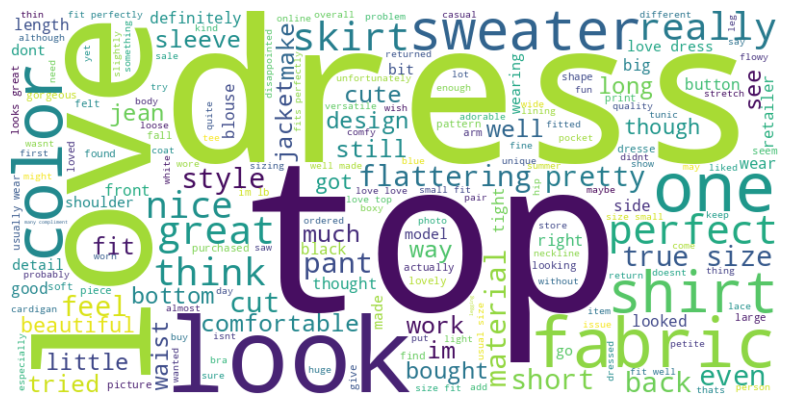

In [ ]:
from wordcloud import WordCloud

# Tüm temizlenmiş metinleri birleştirelim
all_words = " ".join(df['Clean_Review'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

# 1. Veriyi Eğitim ve Test olarak bölelim (%80 Eğitim, %20 Test)
X = df['Clean_Review'].values
y = df['Sentiment'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
# 'stratify=y' yaparak her iki sette de olumlu/olumsuz oranının aynı kalmasını sağladık.

# 2. Tokenizer'ı hazırlayalım
max_words = 10000 # En sık kullanılan 10 bin kelimeyi al
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

# 3. Metinleri sayı dizilerine çevirelim
X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_test_sequences = tokenizer.texts_to_sequences(X_test)

# 4. Padding (Hizalama) - Tüm cümleleri 100 kelimeye sabitleyelim
max_len = 100
X_train_padded = pad_sequences(X_train_sequences, maxlen=max_len, padding='post', truncating='post')
X_test_padded = pad_sequences(X_test_sequences, maxlen=max_len, padding='post', truncating='post')

print("Ön işleme ve sayısallaştırma tamamlandı!")
print(f"Eğitim verisi şekli: {X_train_padded.shape}")
print(f"Örnek bir yorumun sayısal hali:\n{X_train_padded[0]}")

Ön işleme ve sayısallaştırma tamamlandı!
Eğitim verisi şekli: (18112, 100)
Örnek bir yorumun sayısal hali:
[   3   38   58  163 1619   40 4304   40   18  351  250   38    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0]


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D

# Model Mimarisi
model = Sequential()

# 1. Embedding Katmanı: Sayıları 128 boyutlu anlamlı vektörlere dönüştürür
model.add(Embedding(input_dim=10000, output_dim=128, input_length=100))

# 2. Dropout: Aşırı öğrenmeyi (overfitting) engellemek için bazı nöronları rastgele kapatır
model.add(SpatialDropout1D(0.2))

# 3. LSTM Katmanı: Metnin sırasını ve uzun vadeli ilişkileri anlar
model.add(LSTM(64, dropout=0.2, recurrent_dropout=0.2))

# 4. Çıkış Katmanı: Binary (ikili) sınıflandırma yapacağı için Sigmoid kullanıyoruz
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

print(model.summary())

# Modeli Eğitme
print("\nEğitim başlıyor...")
history = model.fit(
    X_train_padded, y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_test_padded, y_test),
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None

Eğitim başlıyor...
Epoch 1/5
283/283 ━━━━━━━━━━━━━━━━━━━━ 81s 255ms/step - accuracy: 0.7684 - loss: 0.5427 - val_accuracy: 0.7706 - val_loss: 0.5388
Epoch 2/5
283/283 ━━━━━━━━━━━━━━━━━━━━ 71s 252ms/step - accuracy: 0.7706 - loss: 0.5399 - val_accuracy: 0.7706 - val_loss: 0.5386
Epoch 3/5
283/283 ━━━━━━━━━━━━━━━━━━━━ 81s 249ms/step - accuracy: 0.7706 - loss: 0.5396 - val_accuracy: 0.7706 - val_loss: 0.5386
Epoch 4/5
283/283 ━━━━━━━━━━━━━━━━━━━━ 83s 252ms/step - accuracy: 0.7706 - loss: 0.5388 - val_accuracy: 0.7706 - val_loss: 0.5386
Epoch 5/5
283/283 ━━━━━━━━━━━━━━━━━━━━ 76s 270ms/step - accuracy: 0.7706 - loss: 0.5389 - val_accuracy: 0.7706 - val_loss: 0.5415


In [ ]:
from sklearn.utils import class_weight
import numpy as np

# 1. Sınıf ağırlıklarını hesapla (Dengesizliği gidermek için)
weights = class_weight.compute_class_weight('balanced',
                                            classes=np.unique(y_train),
                                            y=y_train)
class_weights_dict = {0: weights[0], 1: weights[1]}

print(f"Hesaplanan Ağırlıklar: {class_weights_dict}")

# 2. Modeli tekrar derleyelim (Öğrenme oranını biraz düşürelim: default 0.001'den 0.0005'e)
from tensorflow.keras.optimizers import Adam
model.compile(loss='binary_crossentropy',
              optimizer=Adam(learning_rate=0.0005),
              metrics=['accuracy'])

# 3. Eğitimi 'class_weight' parametresi ile tekrar başlatalım
history = model.fit(
    X_train_padded, y_train,
    epochs=10, # Biraz daha süre verelim
    batch_size=32, # Daha küçük batch, daha sık güncelleme
    validation_data=(X_test_padded, y_test),
    class_weight=class_weights_dict,
    verbose=1
)

Hesaplanan Ağırlıklar: {0: np.float64(2.1800674049109294), 1: np.float64(0.6488035535176959)}
Epoch 1/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 159s 267ms/step - accuracy: 0.5543 - loss: 0.7034 - val_accuracy: 0.7706 - val_loss: 0.6811
Epoch 2/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 147s 260ms/step - accuracy: 0.5103 - loss: 0.6938 - val_accuracy: 0.7706 - val_loss: 0.6720
Epoch 3/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 195s 248ms/step - accuracy: 0.4996 - loss: 0.6937 - val_accuracy: 0.7706 - val_loss: 0.6735
Epoch 4/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 142s 251ms/step - accuracy: 0.4987 - loss: 0.6938 - val_accuracy: 0.7706 - val_loss: 0.6801
Epoch 5/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 202s 252ms/step - accuracy: 0.5277 - loss: 0.6935 - val_accuracy: 0.7706 - val_loss: 0.6908
Epoch 6/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 141s 250ms/step - accuracy: 0.4759 - loss: 0.6934 - val_accuracy: 0.7706 - val_loss: 0.6738
Epoch 7/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 142s 250ms/step - accuracy: 0.5529 - loss: 0.6934 - val_accuracy: 0.2294 -

In [ ]:
!pip install transformers datasets

In [ ]:
import torch
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset

# 1. Tokenizer'ı yükleyelim
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

# 2. Veriyi Hugging Face Dataset formatına çevirelim
train_data = Dataset.from_dict({"text": X_train, "label": y_train})
test_data = Dataset.from_dict({"text": X_test, "label": y_test})

# 3. Tokenization fonksiyonu
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

tokenized_train = train_data.map(tokenize_function, batched=True)
tokenized_test = test_data.map(tokenize_function, batched=True)

# 4. Modeli yükleyelim (2 sınıf: Olumlu/Olumsuz)
model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/18112 [00:00<?, ? examples/s]

Map:   0%|          | 0/4529 [00:00<?, ? examples/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from transformers import TrainingArguments, Trainer

# Parametreyi 'eval_strategy' olarak güncelledik
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    eval_strategy="epoch", # Burayı düzelttik
    save_strategy="epoch",
    load_best_model_at_end=True
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
)

print("DistilBERT eğitimi nihayet başlıyor. GPU devrede...")
trainer.train()

DistilBERT eğitimi nihayet başlıyor. GPU devrede...


Epoch,Training Loss,Validation Loss
1,0.288147,0.279226
2,0.218811,0.279010


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=2264, training_loss=0.27956145559519846, metrics={'train_runtime': 480.9235, 'train_samples_per_second': 75.322, 'train_steps_per_second': 4.708, 'total_flos': 1199624762228736.0, 'train_loss': 0.27956145559519846, 'epoch': 2.0})

In [ ]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.4 MB/s eta 0:00:00


In [ ]:
import numpy as np
import evaluate

# Yeni 'evaluate' kütüphanesini kullanalım
accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    # Logit değerlerini (olasılıkları) sınıflara (0 veya 1) çeviriyoruz
    predictions = np.argmax(logits, axis=-1)
    return accuracy_metric.compute(predictions=predictions, references=labels)

# Trainer'a metrik fonksiyonunu bağlayalım
trainer.compute_metrics = compute_metrics

# Şimdi tekrar değerlendirelim
print("Sonuçlar hesaplanıyor...")
metrics = trainer.evaluate()

# Sonuçları ekrana yazdıralım
print("-" * 30)
print(f"Modelin Genel Doğruluk Oranı (Accuracy): %{metrics['eval_accuracy'] * 100:.2f}")
print(f"Test Kaybı (Loss): {metrics['eval_loss']:.4f}")
print("-" * 30)

Sonuçlar hesaplanıyor...


------------------------------
Modelin Genel Doğruluk Oranı (Accuracy): %88.76
Test Kaybı (Loss): 0.2790
------------------------------


In [ ]:
import torch

def duygu_analizi(yorum):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)

    # Metni işle
    inputs = tokenizer(yorum, return_tensors="pt", padding=True, truncation=True, max_length=128).to(device)

    # Tahmin al
    with torch.no_grad():
        logits = model(**inputs).logits

    # Kararı ver
    predicted_class_id = torch.argmax(logits, dim=1).item()
    duygu = "POZİTİF 😊" if predicted_class_id == 1 else "NEGATİF 😞"

    print(f"Yorum: {yorum}")
    print(f"Modelin Tahmini: {duygu}")
    print("-" * 30)

# Deneyelim
duygu_analizi("I loved the design, but the material was very itchy and uncomfortable.")
duygu_analizi("Best purchase ever! It fits perfectly and the color is vibrant.")

Yorum: I loved the design, but the material was very itchy and uncomfortable.
Modelin Tahmini: NEGATİF 😞
------------------------------
Yorum: Best purchase ever! It fits perfectly and the color is vibrant.
Modelin Tahmini: POZİTİF 😊
------------------------------


In [ ]:
import pandas as pd

# Test setindeki gerçek değerlerle tahminleri karşılaştıralım
predictions_output = trainer.predict(tokenized_test)
preds = np.argmax(predictions_output.predictions, axis=-1)

# Hatalı tahminleri bir DataFrame'e koyalım
hata_df = pd.DataFrame({
    'Yorum': X_test,
    'Gerçek': y_test,
    'Tahmin': preds
})

# Sadece yanlış tahminleri filtrele
yanlislar = hata_df[hata_df['Gerçek'] != hata_df['Tahmin']].head(5)

print("Modelin Yanıldığı Bazı Örnekler:")
print(yanlislar)

Modelin Yanıldığı Bazı Örnekler:
                                                Yorum  Gerçek  Tahmin
15  nice sweater return came late birthday gift gi...       1       0
19  sweater super cute wish worked must like sweat...       1       0
22  although kind ran big material stiff causing p...       1       0
26  love material style versitile skirt however do...       1       0
37  normally wear large give bust beware big chest...       1       0


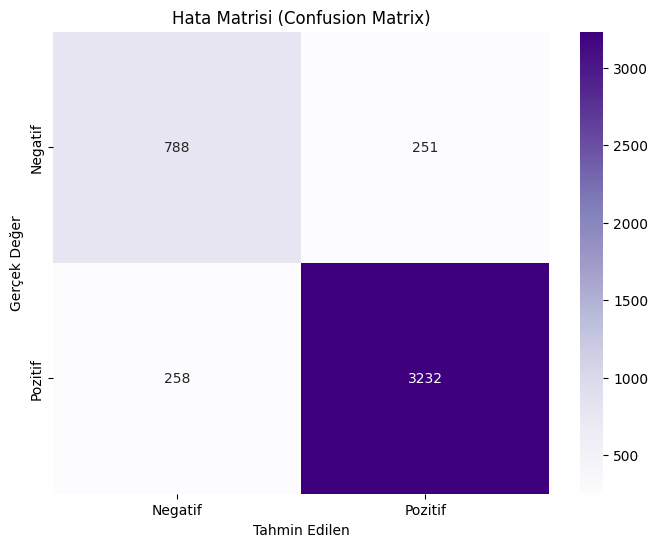

              precision    recall  f1-score   support

 Negatif (0)       0.75      0.76      0.76      1039
 Pozitif (1)       0.93      0.93      0.93      3490

    accuracy                           0.89      4529
   macro avg       0.84      0.84      0.84      4529
weighted avg       0.89      0.89      0.89      4529



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Karmaşıklık matrisini hesapla
cm = confusion_matrix(y_test, preds)

# Görselleştir
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=['Negatif', 'Pozitif'], yticklabels=['Negatif', 'Pozitif'])
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')
plt.title('Hata Matrisi (Confusion Matrix)')
plt.show()

# Detaylı rapor (Precision, Recall, F1-Score)
print(classification_report(y_test, preds, target_names=['Negatif (0)', 'Pozitif (1)']))

In [ ]:
import torch
import torch.nn.functional as F

def model_test_et(yorum):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)

    # Metni işle
    inputs = tokenizer(yorum, return_tensors="pt", padding=True, truncation=True, max_length=128).to(device)

    # Tahmin al
    with torch.no_grad():
        logits = model(**inputs).logits
        # Olasılıkları hesapla (Softmax)
        probs = F.softmax(logits, dim=1)
        conf, pred = torch.max(probs, dim=1)

    duygu = "POZİTİF 😊" if pred.item() == 1 else "NEGATİF 😞"
    print(f"Yorum: {yorum}")
    print(f"Sonuç: {duygu} (Eminlik: %{conf.item()*100:.2f})")
    print("-" * 50)

# Örnek Test Listesi
test_listesi = [
    "I love the color, but the fabric is so thin and see-through. I had to return it.",
    "This is the best dress I have ever bought! It fits like a glove.",
    "The sizing is completely wrong. I usually wear a small but this felt like an XL.",
    "It's a nice shirt but it arrived with a hole in the sleeve. Very disappointing.",
    "Beautiful design and very high quality material. Worth every penny!"
]

for ornek in test_listesi:
    model_test_et(ornek)

Yorum: I love the color, but the fabric is so thin and see-through. I had to return it.
Sonuç: NEGATİF 😞 (Eminlik: %75.74)
--------------------------------------------------
Yorum: This is the best dress I have ever bought! It fits like a glove.
Sonuç: POZİTİF 😊 (Eminlik: %97.94)
--------------------------------------------------
Yorum: The sizing is completely wrong. I usually wear a small but this felt like an XL.
Sonuç: NEGATİF 😞 (Eminlik: %90.67)
--------------------------------------------------
Yorum: It's a nice shirt but it arrived with a hole in the sleeve. Very disappointing.
Sonuç: NEGATİF 😞 (Eminlik: %95.57)
--------------------------------------------------
Yorum: Beautiful design and very high quality material. Worth every penny!
Sonuç: POZİTİF 😊 (Eminlik: %87.22)
--------------------------------------------------


In [ ]:
import os
from google.colab import files

# 1. Klasör yolunu belirle
model_yolu = "kadin_giyim_duygu_modeli"

# 2. Modeli ve Tokenizer'ı kaydet
trainer.save_model(model_yolu)
tokenizer.save_pretrained(model_yolu)

# 3. Klasörü zip dosyasına dönüştür
!zip -r model_dosyasi.zip {model_yolu}

# 4. Dosyayı indir
files.download("model_dosyasi.zip")

print("Model başarıyla paketlendi ve indirme işlemi başlatıldı!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  adding: kadin_giyim_duygu_modeli/ (stored 0%)
  adding: kadin_giyim_duygu_modeli/training_args.bin (deflated 53%)
  adding: kadin_giyim_duygu_modeli/model.safetensors (deflated 8%)
  adding: kadin_giyim_duygu_modeli/config.json (deflated 49%)
  adding: kadin_giyim_duygu_modeli/tokenizer_config.json (deflated 42%)
  adding: kadin_giyim_duygu_modeli/tokenizer.json (deflated 71%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model başarıyla paketlendi ve indirme işlemi başlatıldı!
